In [ ]:
# =====================================================
# CELL 1: INSTALL DEPENDENCIES
# YELP REVIEW POLARITY - T5 ABSTRACTIVE SUMMARISATION
# LONG-RUN RESUME-SAFE VERSION
# =====================================================
!pip install -q pandas numpy nltk transformers sentencepiece accelerate tqdm rouge-score scikit-learn

In [ ]:
# =====================================================
# CELL 2: IMPORT LIBRARIES + MOUNT GOOGLE DRIVE
# =====================================================
import os
import re
import gc
import json
import time
import numpy as np
import pandas as pd
import nltk
import torch

from tqdm import tqdm
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from rouge_score import rouge_scorer

from google.colab import drive
drive.mount("/content/drive")

nltk.download("punkt")
nltk.download("punkt_tab")

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Torch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
# =====================================================
# CELL 3: PATHS + CONFIG
# =====================================================
TRAIN_PATH = "/content/drive/MyDrive/yelp_review_polarity_csv/train.csv"
TEST_PATH = "/content/drive/MyDrive/yelp_review_polarity_csv/test.csv"

OUTPUT_DIR = "/content/drive/MyDrive/yelp_t5_abstractive_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SEED = 42
VAL_SIZE = 0.1

# -------------------------
# T5 model and parameters
# Same as IMDb T5 where possible
# -------------------------
MODEL_NAME = "t5-small"

MAX_INPUT_LENGTH = 512
MAX_SUMMARY_LENGTH = 80
MIN_SUMMARY_LENGTH = 20
NUM_BEAMS = 2
LENGTH_PENALTY = 2.0
EARLY_STOPPING = True

# A100-friendly runtime settings
BATCH_SIZE = 32 if torch.cuda.is_available() else 2
CHECKPOINT_EVERY = 100

EVAL_SAMPLE_SIZE = 2000

RUN_NAME = "yelp_t5_abstractive"

print("Output folder:", OUTPUT_DIR)
print("Model name   :", MODEL_NAME)
print("Batch size   :", BATCH_SIZE)
print("Checkpoint every:", CHECKPOINT_EVERY, "batches")

Output folder: /content/drive/MyDrive/yelp_t5_abstractive_outputs
Model name   : t5-small
Batch size   : 32
Checkpoint every: 100 batches


In [ ]:
# =====================================================
# CELL 4: LOAD YELP DATASET
# =====================================================
train_df = pd.read_csv(TRAIN_PATH, header=None, names=["label", "text"])
test_df = pd.read_csv(TEST_PATH, header=None, names=["label", "text"])

print("Original shapes:")
print("train.csv:", train_df.shape)
print("test.csv :", test_df.shape)

# Original Yelp labels:
# 1 = negative, 2 = positive
label_map = {1: 0, 2: 1}

train_df["label"] = train_df["label"].map(label_map)
test_df["label"] = test_df["label"].map(label_map)

print("\nLabel distribution before cleaning:")
print("Train:\n", train_df["label"].value_counts().sort_index())
print("Test:\n", test_df["label"].value_counts().sort_index())

Original shapes:
train.csv: (560000, 2)
test.csv : (38000, 2)

Label distribution before cleaning:
Train:
 label
0    280000
1    280000
Name: count, dtype: int64
Test:
 label
0    19000
1    19000
Name: count, dtype: int64


In [ ]:
# =====================================================
# CELL 5: CLEAN TEXT + TRAIN/VAL SPLIT
# =====================================================
def clean_text(text):
    text = str(text)
    text = text.replace("<br />", " ")
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

# Clean text
train_df["text"] = train_df["text"].astype(str).apply(clean_text)
test_df["text"] = test_df["text"].astype(str).apply(clean_text)

# Remove empty rows
train_df = train_df[train_df["text"].str.len() > 0].reset_index(drop=True)
test_df = test_df[test_df["text"].str.len() > 0].reset_index(drop=True)

# Stratified validation split from train
train_split_df, val_df = train_test_split(
    train_df,
    test_size=VAL_SIZE,
    stratify=train_df["label"],
    random_state=SEED
)

train_split_df = train_split_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Final split sizes:")
print("Train:", len(train_split_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

print("\nLabel distributions:")
print("Train:\n", train_split_df["label"].value_counts(normalize=True).sort_index())
print("Val:\n", val_df["label"].value_counts(normalize=True).sort_index())
print("Test:\n", test_df["label"].value_counts(normalize=True).sort_index())

# Save exact splits used
train_split_df.to_csv(os.path.join(OUTPUT_DIR, "train_split_used.csv"), index=False)
val_df.to_csv(os.path.join(OUTPUT_DIR, "val_split_used.csv"), index=False)
test_df.to_csv(os.path.join(OUTPUT_DIR, "test_split_used.csv"), index=False)

Final split sizes:
Train: 503994
Val  : 56000
Test : 38000

Label distributions:
Train:
 label
0    0.5
1    0.5
Name: proportion, dtype: float64
Val:
 label
0    0.5
1    0.5
Name: proportion, dtype: float64
Test:
 label
0    0.5
1    0.5
Name: proportion, dtype: float64


In [ ]:
# =====================================================
# CELL 6: PREPARE TEXT/LABEL LISTS
# =====================================================
train_texts = train_split_df["text"].tolist()
val_texts = val_df["text"].tolist()
test_texts = test_df["text"].tolist()

train_labels = train_split_df["label"].tolist()
val_labels = val_df["label"].tolist()
test_labels = test_df["label"].tolist()

print("Prepared lists:")
print("Train:", len(train_texts), len(train_labels))
print("Val  :", len(val_texts), len(val_labels))
print("Test :", len(test_texts), len(test_labels))

Prepared lists:
Train: 503994 503994
Val  : 56000 56000
Test : 38000 38000


In [ ]:
# =====================================================
# CELL 7: LOAD T5 MODEL
# =====================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

print("Running on:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    torch.cuda.empty_cache()

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Running on: cuda
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
# =====================================================
# CELL 8: BATCH SUMMARY GENERATION
# =====================================================
def generate_summary_batch(text_batch):
    """
    T5 requires task prefix:
    summarize: <text>
    """

    prefixed_batch = [f"summarize: {str(t).strip()}" for t in text_batch]

    inputs = tokenizer(
        prefixed_batch,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=MAX_INPUT_LENGTH
    ).to(device)

    with torch.no_grad():
        summary_ids = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_length=MAX_SUMMARY_LENGTH,
            min_length=MIN_SUMMARY_LENGTH,
            num_beams=NUM_BEAMS,
            length_penalty=LENGTH_PENALTY,
            early_stopping=EARLY_STOPPING
        )

    summaries = tokenizer.batch_decode(
        summary_ids,
        skip_special_tokens=True
    )

    return [s.strip() for s in summaries]

In [ ]:
# =====================================================
# CELL 9: SAFE APPEND CHECKPOINT SUMMARISATION
# Use this instead of the old rewriting checkpoint cell
# =====================================================
def get_output_csv_path(split_name):
    return os.path.join(OUTPUT_DIR, f"{RUN_NAME}_{split_name}.csv")

def get_checkpoint_path(split_name):
    return os.path.join(OUTPUT_DIR, f"{RUN_NAME}_{split_name}_checkpoint.json")

def get_time_path(split_name):
    return os.path.join(OUTPUT_DIR, f"{RUN_NAME}_{split_name}_time.json")


def load_resume_state(split_name):
    csv_path = get_output_csv_path(split_name)
    ckpt_path = get_checkpoint_path(split_name)

    completed = 0

    if os.path.exists(csv_path):
        try:
            existing_df = pd.read_csv(csv_path)
            completed = len(existing_df)
            print(f"Found existing {split_name} CSV with {completed} rows.")
        except Exception as e:
            print(f"Could not read CSV for {split_name}: {e}")
            completed = 0

    if os.path.exists(ckpt_path):
        try:
            with open(ckpt_path, "r") as f:
                ckpt = json.load(f)
            completed = max(completed, ckpt.get("rows_saved", 0))
            print(f"Found checkpoint for {split_name}: {ckpt}")
        except Exception as e:
            print(f"Could not read checkpoint for {split_name}: {e}")

    return completed


def save_resume_state(split_name, rows_saved):
    ckpt_path = get_checkpoint_path(split_name)
    with open(ckpt_path, "w") as f:
        json.dump({"rows_saved": int(rows_saved)}, f)


def append_batch_to_csv(split_name, batch_texts, batch_summaries, batch_labels):
    csv_path = get_output_csv_path(split_name)

    batch_df = pd.DataFrame({
        "original_text": batch_texts,
        "summary_text": batch_summaries,
        "label": batch_labels
    })

    file_exists = os.path.exists(csv_path)
    batch_df.to_csv(csv_path, mode="a", header=not file_exists, index=False)


def save_elapsed_time(split_name, elapsed_seconds):
    time_path = get_time_path(split_name)
    with open(time_path, "w") as f:
        json.dump({"elapsed_seconds": float(elapsed_seconds)}, f)


def load_elapsed_time(split_name):
    time_path = get_time_path(split_name)
    if os.path.exists(time_path):
        try:
            with open(time_path, "r") as f:
                return json.load(f).get("elapsed_seconds", 0.0)
        except Exception:
            return 0.0
    return 0.0


def summarise_with_resume_append(texts, labels, split_name):
    completed = load_resume_state(split_name)
    previous_elapsed = load_elapsed_time(split_name)

    if completed >= len(texts):
        print(f"{split_name} already completed.")
        return completed, previous_elapsed

    print(f"Resuming {split_name} from row {completed}")

    start_time = time.time()

    for batch_idx, start in enumerate(
        tqdm(range(completed, len(texts), BATCH_SIZE), desc=f"Summarising {split_name}"),
        start=1
    ):
        end = min(start + BATCH_SIZE, len(texts))

        batch_texts = texts[start:end]
        batch_labels = labels[start:end]

        try:
            batch_summaries = generate_summary_batch(batch_texts)
        except Exception as e:
            print(f"\nError at batch {start}-{end}: {e}")
            batch_summaries = [""] * len(batch_texts)

        append_batch_to_csv(
            split_name,
            batch_texts,
            batch_summaries,
            batch_labels
        )

        rows_saved = end

        if batch_idx % CHECKPOINT_EVERY == 0 or end == len(texts):
            elapsed_so_far = previous_elapsed + (time.time() - start_time)
            save_resume_state(split_name, rows_saved)
            save_elapsed_time(split_name, elapsed_so_far)
            print(f"\nCheckpoint saved: {split_name} row {rows_saved}")

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    elapsed = previous_elapsed + (time.time() - start_time)

    save_resume_state(split_name, len(texts))
    save_elapsed_time(split_name, elapsed)

    print(f"\nFinished {split_name}")
    print("Rows saved:", len(texts))
    print("Elapsed minutes:", round(elapsed / 60, 2))

    return len(texts), elapsed

In [ ]:
# =====================================================
# CELL 10A: RUN TRAIN T5 SUMMARISATION ONLY
# =====================================================
train_done, train_time = summarise_with_resume_append(
    train_texts,
    train_labels,
    "train"
)

print("Train rows completed:", train_done)
print("Train time (hours):", round(train_time / 3600, 2))

Resuming train from row 0


Summarising train:   1%|          | 99/15750 [02:20<5:59:43,  1.38s/it]


Checkpoint saved: train row 3200


Summarising train:   1%|▏         | 199/15750 [04:41<6:00:38,  1.39s/it]


Checkpoint saved: train row 6400


...


Checkpoint saved: train row 502400


Summarising train: 100%|█████████▉| 15749/15750 [6:05:19<00:01,  1.36s/it]


Checkpoint saved: train row 503994


Summarising train: 100%|██████████| 15750/15750 [6:05:20<00:00,  1.39s/it]


Finished train
Rows saved: 503994
Elapsed minutes: 365.35
Train rows completed: 503994
Train time (hours): 6.09


In [ ]:
# =====================================================
# CELL 10B: RUN VALIDATION T5 SUMMARISATION ONLY
# =====================================================
val_done, val_time = summarise_with_resume_append(
    val_texts,
    val_labels,
    "val"
)

print("Validation rows completed:", val_done)
print("Validation time (hours):", round(val_time / 3600, 2))

Resuming val from row 0


Summarising val:   6%|▌         | 99/1750 [02:19<38:33,  1.40s/it]


Checkpoint saved: val row 3200


Summarising val:  11%|█▏        | 199/1750 [04:37<36:13,  1.40s/it]


Checkpoint saved: val row 6400


...


Checkpoint saved: val row 54400


Summarising val: 100%|█████████▉| 1749/1750 [40:22<00:01,  1.45s/it]


Checkpoint saved: val row 56000


Summarising val: 100%|██████████| 1750/1750 [40:24<00:00,  1.39s/it]


Finished val
Rows saved: 56000
Elapsed minutes: 40.41
Validation rows completed: 56000
Validation time (hours): 0.67


In [ ]:
# =====================================================
# CELL 10C: RUN TEST T5 SUMMARISATION ONLY
# =====================================================
test_done, test_time = summarise_with_resume_append(
    test_texts,
    test_labels,
    "test"
)

print("Test rows completed:", test_done)
print("Test time (hours):", round(test_time / 3600, 2))

Resuming test from row 0


Summarising test:   8%|▊         | 99/1188 [02:16<24:35,  1.35s/it]


Checkpoint saved: test row 3200


Summarising test:  17%|█▋        | 199/1188 [04:34<23:02,  1.40s/it]


Checkpoint saved: test row 6400


...


Checkpoint saved: test row 35200


Summarising test: 100%|█████████▉| 1187/1188 [27:30<00:01,  1.34s/it]


Checkpoint saved: test row 38000


Summarising test: 100%|██████████| 1188/1188 [27:32<00:00,  1.39s/it]


Finished test
Rows saved: 38000
Elapsed minutes: 27.54
Test rows completed: 38000
Test time (hours): 0.46


In [ ]:
# =====================================================
# CELL 11: LOAD COMPLETED T5 SUMMARY FILES
# =====================================================
train_summary_df = pd.read_csv(os.path.join(OUTPUT_DIR, f"{RUN_NAME}_train.csv"))
val_summary_df   = pd.read_csv(os.path.join(OUTPUT_DIR, f"{RUN_NAME}_val.csv"))
test_summary_df  = pd.read_csv(os.path.join(OUTPUT_DIR, f"{RUN_NAME}_test.csv"))

print("Train:", train_summary_df.shape)
print("Val  :", val_summary_df.shape)
print("Test :", test_summary_df.shape)

display(train_summary_df.head())

Train: (503994, 3)
Val  : (56000, 3)
Test : (38000, 3)


,original_text,summary_text,label
0,Always has been good!,always has been good!!!!!!!!,1
1,I love the cheap drinks. Cheaper than QT even....,nnBUT the person who takes the drive thru orde...,0
2,Im giving to stars because of the clerks insid...,i drive a lowered bmw E36 the fucking idiot da...,0
3,"Excellent food, great service.\n\nThe pulled p...","the pulled pork tacos are excellent, as is the...",1
4,Paid $18.00 for bulgogi and they gave us liter...,bulgogi paid $18.00 for bulgogi. took 10 minut...,0


In [ ]:
# =====================================================
# CELL 12: SAVE CLASSIFICATION-READY FILES
# =====================================================
train_for_cls = train_summary_df[["summary_text", "label"]].rename(
    columns={"summary_text": "text"}
)

val_for_cls = val_summary_df[["summary_text", "label"]].rename(
    columns={"summary_text": "text"}
)

test_for_cls = test_summary_df[["summary_text", "label"]].rename(
    columns={"summary_text": "text"}
)

train_cls_path = os.path.join(
    OUTPUT_DIR, f"{RUN_NAME}_train_for_classification.csv"
)
val_cls_path = os.path.join(
    OUTPUT_DIR, f"{RUN_NAME}_val_for_classification.csv"
)
test_cls_path = os.path.join(
    OUTPUT_DIR, f"{RUN_NAME}_test_for_classification.csv"
)

train_for_cls.to_csv(train_cls_path, index=False)
val_for_cls.to_csv(val_cls_path, index=False)
test_for_cls.to_csv(test_cls_path, index=False)

print("Saved:")
print(train_cls_path)
print(val_cls_path)
print(test_cls_path)

Saved:
/content/drive/MyDrive/yelp_t5_abstractive_outputs/yelp_t5_abstractive_train_for_classification.csv
/content/drive/MyDrive/yelp_t5_abstractive_outputs/yelp_t5_abstractive_val_for_classification.csv
/content/drive/MyDrive/yelp_t5_abstractive_outputs/yelp_t5_abstractive_test_for_classification.csv


In [ ]:
# =====================================================
# CELL 13: EVALUATION FUNCTION
# =====================================================
def evaluate_abstractive_summaries(original_texts, summary_texts, dataset_name):
    original_word_counts = []
    summary_word_counts = []
    original_sentence_counts = []
    summary_sentence_counts = []

    rouge1_scores = []
    rouge2_scores = []
    rougeL_scores = []
    bleu_scores = []

    scorer = rouge_scorer.RougeScorer(
        ["rouge1", "rouge2", "rougeL"],
        use_stemmer=True
    )

    smoothie = SmoothingFunction().method1

    if EVAL_SAMPLE_SIZE is not None and len(original_texts) > EVAL_SAMPLE_SIZE:
        rng = np.random.default_rng(SEED)
        idx = rng.choice(
            len(original_texts),
            size=EVAL_SAMPLE_SIZE,
            replace=False
        )

        original_eval = [original_texts[i] for i in idx]
        summary_eval = [summary_texts[i] for i in idx]
    else:
        original_eval = list(original_texts)
        summary_eval = list(summary_texts)

    for original, summary in tqdm(
        zip(original_eval, summary_eval),
        total=len(original_eval),
        desc=f"Evaluating {dataset_name}"
    ):
        original = str(original)
        summary = str(summary)

        original_word_counts.append(len(word_tokenize(original)))
        summary_word_counts.append(len(word_tokenize(summary)))

        original_sentence_counts.append(len(sent_tokenize(original)))
        summary_sentence_counts.append(len(sent_tokenize(summary)))

        reference = " ".join(sent_tokenize(original)[:2])

        try:
            scores = scorer.score(reference, summary)
            rouge1_scores.append(scores["rouge1"].fmeasure)
            rouge2_scores.append(scores["rouge2"].fmeasure)
            rougeL_scores.append(scores["rougeL"].fmeasure)
        except:
            rouge1_scores.append(np.nan)
            rouge2_scores.append(np.nan)
            rougeL_scores.append(np.nan)

        try:
            bleu_scores.append(
                sentence_bleu(
                    [reference.split()],
                    summary.split(),
                    smoothing_function=smoothie
                )
            )
        except:
            bleu_scores.append(np.nan)

    avg_original_words = np.mean(original_word_counts)
    avg_summary_words = np.mean(summary_word_counts)

    avg_original_sentences = np.mean(original_sentence_counts)
    avg_summary_sentences = np.mean(summary_sentence_counts)

    return {
        "dataset": dataset_name,
        "avg_original_words": round(avg_original_words, 2),
        "avg_summary_words": round(avg_summary_words, 2),
        "avg_original_sentences": round(avg_original_sentences, 2),
        "avg_summary_sentences": round(avg_summary_sentences, 2),
        "word_compression_ratio": round(avg_summary_words / avg_original_words, 4),
        "sentence_compression_ratio": round(avg_summary_sentences / avg_original_sentences, 4),
        "rouge_1": round(np.nanmean(rouge1_scores), 4),
        "rouge_2": round(np.nanmean(rouge2_scores), 4),
        "rouge_L": round(np.nanmean(rougeL_scores), 4),
        "bleu": round(np.nanmean(bleu_scores), 4),
    }

In [ ]:
# =====================================================
# CELL 14: RUN EVALUATION + SAVE RESULTS
# =====================================================
evaluation_results = []

evaluation_results.append(
    evaluate_abstractive_summaries(
        train_summary_df["original_text"].tolist(),
        train_summary_df["summary_text"].tolist(),
        f"{RUN_NAME}_train"
    )
)

evaluation_results.append(
    evaluate_abstractive_summaries(
        val_summary_df["original_text"].tolist(),
        val_summary_df["summary_text"].tolist(),
        f"{RUN_NAME}_val"
    )
)

evaluation_results.append(
    evaluate_abstractive_summaries(
        test_summary_df["original_text"].tolist(),
        test_summary_df["summary_text"].tolist(),
        f"{RUN_NAME}_test"
    )
)

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_path = os.path.join(
    OUTPUT_DIR,
    f"{RUN_NAME}_evaluation.csv"
)

evaluation_df.to_csv(evaluation_path, index=False)

print("Saved evaluation results:")
print(evaluation_path)

display(evaluation_df)

Evaluating yelp_t5_abstractive_test: 100%|██████████| 2000/2000 [00:04<00:00, 427.28it/s]

Saved evaluation results:
/content/drive/MyDrive/yelp_t5_abstractive_outputs/yelp_t5_abstractive_evaluation.csv


,dataset,avg_original_words,avg_summary_words,avg_original_sentences,avg_summary_sentences,word_compression_ratio,sentence_compression_ratio,rouge_1,rouge_2,rouge_L,bleu
0,yelp_t5_abstractive_train,149.56,30.27,8.44,2.27,0.2024,0.2691,0.3958,0.2904,0.3546,0.1914
1,yelp_t5_abstractive_val,157.31,30.36,8.65,2.23,0.1930,0.2578,0.4016,0.2988,0.3599,0.1953
2,yelp_t5_abstractive_test,154.44,30.34,8.67,2.27,0.1964,0.2617,0.3902,0.2846,0.3504,0.1873


In [ ]:
# =====================================================
# CELL 15: GENERATION TIME SUMMARY
# =====================================================
time_records = []

for split_name in ["train", "val", "test"]:
    elapsed = load_elapsed_time(split_name)

    if elapsed > 0:
        time_records.append({
            "split": split_name,
            "generation_time_sec": round(elapsed, 2),
            "generation_time_hr": round(elapsed / 3600, 2)
        })

time_df = pd.DataFrame(time_records)

time_path = os.path.join(
    OUTPUT_DIR,
    f"{RUN_NAME}_generation_times.csv"
)

time_df.to_csv(time_path, index=False)

print("Saved generation times:")
print(time_path)

display(time_df)

In [ ]:
# =====================================================
# CELL 16: FINAL SUMMARY
# =====================================================
print("=" * 70)
print("T5 YELP SUMMARISATION PIPELINE COMPLETE")
print("=" * 70)

print("\nMain output folder:")
print(OUTPUT_DIR)

print("\nClassification-ready files:")
print(f"{RUN_NAME}_train_for_classification.csv")
print(f"{RUN_NAME}_val_for_classification.csv")
print(f"{RUN_NAME}_test_for_classification.csv")

print("\nEvaluation files:")
print(f"{RUN_NAME}_evaluation.csv")
print(f"{RUN_NAME}_generation_times.csv")

print("\nNext step:")
print("Use these files for BERT / XLNet classification experiments.")

T5 YELP SUMMARISATION PIPELINE COMPLETE

Main output folder:
/content/drive/MyDrive/yelp_t5_abstractive_outputs

Classification-ready files:
yelp_t5_abstractive_train_for_classification.csv
yelp_t5_abstractive_val_for_classification.csv
yelp_t5_abstractive_test_for_classification.csv

Evaluation files:
yelp_t5_abstractive_evaluation.csv
yelp_t5_abstractive_generation_times.csv

Next step:
Use these files for BERT / XLNet classification experiments.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: NVIDIA A100-SXM4-40GB
Train: True /content/drive/MyDrive/yelp_t5_abstractive_outputs/yelp_t5_abstractive_train_for_classification.csv
Val  : True /content/drive/MyDrive/yelp_t5_abstractive_outputs/yelp_t5_abstractive_val_for_classification.csv
Test : True /content/drive/MyDrive/yelp_t5_abstractive_outputs/yelp_t5_abstractive_test_for_classification.csv
Train: 503994
Val  : 56000
Test : 38000


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.329935,0.310377,0.889661,0.870639,0.915321,0.892421,0.957931
2,0.269296,0.351011,0.896036,0.891948,0.901250,0.896575,0.960556


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


=== FINAL BERT T5 RESULTS ===
Accuracy : 0.8957
Precision: 0.8928
Recall   : 0.8994
F1       : 0.8961
ROC-AUC  : 0.9601
Training time: 118 min 12.85 sec
Inference time: 1 min 19.91 sec
Inference latency per sample (ms): 2.103
Training throughput: 71.06 samples/sec
Inference throughput: 475.51 samples/sec

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.90      0.89      0.90     19000
    Positive       0.89      0.90      0.90     19000

    accuracy                           0.90     38000
   macro avg       0.90      0.90      0.90     38000
weighted avg       0.90      0.90      0.90     38000



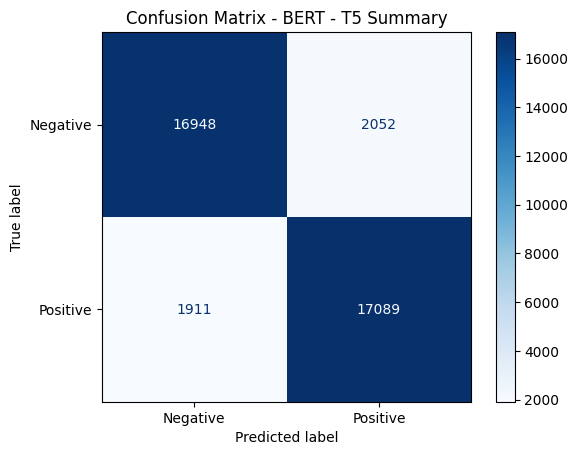

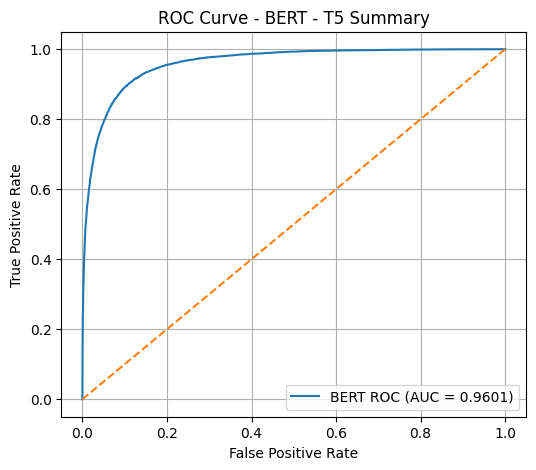

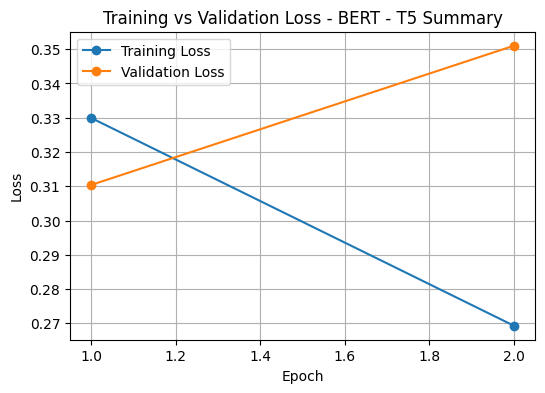


Saved final result:
/content/drive/MyDrive/yelp_t5_classification_outputs/bert_t5_results_final.csv

Saved full artifacts to:
/content/drive/MyDrive/yelp_t5_classification_outputs/bert_t5_single_summary


,Input Type,Summary Method,Summary Length,Model,Checkpoint,Optimizer,Max Length,Batch Size,Epochs,Learning Rate,...,Test Truncation %,Training Time (min),Training Time per Epoch (min),Inference Time (sec),Inference Latency per Sample (ms),Training Throughput (samples/sec),Inference Throughput (samples/sec),Peak Training GPU Memory (MB),Peak Inference GPU Memory (MB),Device
0,Summarised Text,T5,Single Abstractive Summary,BERT,bert-base-uncased,AdamW,256,8,2,0.00002,...,0.01,118.21,59.11,79.91,2.103,71.06,475.51,3464.07,2667.76,NVIDIA A100-SXM4-40GB


In [ ]:
# =====================================================
# YELP T5 SUMMARY CLASSIFICATION
# BERT ONLY + FULL THESIS OUTPUTS
# =====================================================

!pip install -q pandas numpy matplotlib scikit-learn transformers datasets sentencepiece accelerate torch

import os, gc, re, time, random, warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
    EarlyStoppingCallback, set_seed
)

from google.colab import drive
drive.mount("/content/drive")

warnings.filterwarnings("ignore")

# =====================================================
# CONFIG
# =====================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print("Device:", device_name)

BASE_DIR = "/content/drive/MyDrive/yelp_t5_abstractive_outputs"
RUN_OUTPUT_DIR = "/content/drive/MyDrive/yelp_t5_classification_outputs"
OUTPUT_DIR = os.path.join(RUN_OUTPUT_DIR, "bert_t5_single_summary")
os.makedirs(OUTPUT_DIR, exist_ok=True)

TRAIN_PATH = f"{BASE_DIR}/yelp_t5_abstractive_train_for_classification.csv"
VAL_PATH = f"{BASE_DIR}/yelp_t5_abstractive_val_for_classification.csv"
TEST_PATH = f"{BASE_DIR}/yelp_t5_abstractive_test_for_classification.csv"

MODEL_LABEL = "BERT"
MODEL_NAME = "bert-base-uncased"

MAX_LENGTH = 256
EPOCHS = 2
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
BATCH_SIZE = 8
EARLY_STOPPING_PATIENCE = 1
OPTIMIZER_NAME = "AdamW"

FINAL_RESULTS_PATH = os.path.join(RUN_OUTPUT_DIR, "bert_t5_results_final.csv")

print("Train:", os.path.exists(TRAIN_PATH), TRAIN_PATH)
print("Val  :", os.path.exists(VAL_PATH), VAL_PATH)
print("Test :", os.path.exists(TEST_PATH), TEST_PATH)

# =====================================================
# HELPERS
# =====================================================
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)


def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.replace("<br />", " ")
    text = text.replace("\n", " ")
    text = text.replace("\t", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text


def reset_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()


def get_peak_gpu_memory_mb():
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / (1024 ** 2)
    return None


def format_seconds(seconds):
    if seconds < 60:
        return f"{seconds:.2f} sec"
    minutes = int(seconds // 60)
    rem = seconds % 60
    return f"{minutes} min {rem:.2f} sec"


@dataclass
class TokenStats:
    avg_tokens_before: float
    avg_tokens_after: float
    max_tokens_before: int
    truncated_count: int
    truncation_pct: float


def get_token_stats(texts, tokenizer, max_length=256, batch_size=512):
    full_lengths = []
    trunc_lengths = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        full_batch = tokenizer(
            batch,
            add_special_tokens=True,
            truncation=False,
            padding=False
        )

        trunc_batch = tokenizer(
            batch,
            truncation=True,
            padding=False,
            max_length=max_length
        )

        full_lengths.extend([len(x) for x in full_batch["input_ids"]])
        trunc_lengths.extend([len(x) for x in trunc_batch["input_ids"]])

    truncated_count = sum(1 for x in full_lengths if x > max_length)

    stats = TokenStats(
        avg_tokens_before=float(np.mean(full_lengths)),
        avg_tokens_after=float(np.mean(trunc_lengths)),
        max_tokens_before=int(np.max(full_lengths)),
        truncated_count=int(truncated_count),
        truncation_pct=float(truncated_count / len(full_lengths) * 100)
    )

    trunc_enc = tokenizer(
        texts,
        truncation=True,
        padding=False,
        max_length=max_length
    )

    return stats, trunc_enc


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, probs)
    }


def plot_confusion_matrix_save(y_true, y_pred, save_path):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"]
    )
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix - BERT - T5 Summary")
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()
    return cm


def plot_roc_curve_save(y_true, y_prob, save_path):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc_value = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"BERT ROC (AUC = {roc_auc_value:.4f})")
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - BERT - T5 Summary")
    plt.legend()
    plt.grid(True)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_train_val_loss_save(trainer, save_path):
    history = trainer.state.log_history
    train_loss, val_loss = [], []
    train_epochs, val_epochs = [], []

    for log in history:
        if "loss" in log and "epoch" in log and "eval_loss" not in log:
            train_loss.append(log["loss"])
            train_epochs.append(log["epoch"])
        if "eval_loss" in log and "epoch" in log:
            val_loss.append(log["eval_loss"])
            val_epochs.append(log["epoch"])

    if len(train_loss) == 0 or len(val_loss) == 0:
        print("Skipping loss plot: insufficient log history.")
        return

    plt.figure(figsize=(6, 4))
    plt.plot(train_epochs, train_loss, marker="o", label="Training Loss")
    plt.plot(val_epochs, val_loss, marker="o", label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss - BERT - T5 Summary")
    plt.legend()
    plt.grid(True)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()

# =====================================================
# LOAD DATA
# =====================================================
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    if "text" not in df.columns or "label" not in df.columns:
        raise ValueError(f"{name} file must contain columns: text, label")

train_texts = train_df["text"].fillna("").astype(str).apply(clean_text).tolist()
val_texts = val_df["text"].fillna("").astype(str).apply(clean_text).tolist()
test_texts = test_df["text"].fillna("").astype(str).apply(clean_text).tolist()

train_labels = train_df["label"].astype(int).tolist()
val_labels = val_df["label"].astype(int).tolist()
test_labels = test_df["label"].astype(int).tolist()

print("Train:", len(train_texts))
print("Val  :", len(val_texts))
print("Test :", len(test_texts))

# =====================================================
# TOKENIZE
# =====================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

train_stats, train_enc = get_token_stats(train_texts, tokenizer, max_length=MAX_LENGTH)
val_stats, val_enc = get_token_stats(val_texts, tokenizer, max_length=MAX_LENGTH)
test_stats, test_enc = get_token_stats(test_texts, tokenizer, max_length=MAX_LENGTH)

print("\n=== TOKEN / TRUNCATION STATS ===")
print("Train avg tokens before trunc:", round(train_stats.avg_tokens_before, 2))
print("Train avg tokens after trunc :", round(train_stats.avg_tokens_after, 2))
print("Train truncation %          :", round(train_stats.truncation_pct, 2))
print("Test avg tokens before trunc:", round(test_stats.avg_tokens_before, 2))
print("Test avg tokens after trunc :", round(test_stats.avg_tokens_after, 2))
print("Test truncation %           :", round(test_stats.truncation_pct, 2))

train_dataset = TextDataset(train_enc, train_labels)
val_dataset = TextDataset(val_enc, val_labels)
test_dataset = TextDataset(test_enc, test_labels)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# =====================================================
# MODEL + TRAINER
# =====================================================
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    save_total_limit=1,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
    optim="adamw_torch"
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)]
)

# =====================================================
# TRAIN
# =====================================================
reset_gpu_memory()
train_start = time.time()
trainer.train()
train_time = time.time() - train_start
peak_train_mem = get_peak_gpu_memory_mb()

# =====================================================
# TEST / INFERENCE
# =====================================================
reset_gpu_memory()
infer_start = time.time()
pred = trainer.predict(test_dataset)
infer_time = time.time() - infer_start
peak_infer_mem = get_peak_gpu_memory_mb()

y_true = np.array(test_labels)
y_pred = np.argmax(pred.predictions, axis=1)
y_prob = torch.softmax(torch.tensor(pred.predictions), dim=1)[:, 1].numpy()

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
roc_auc_value = roc_auc_score(y_true, y_prob)

num_train = len(train_dataset)
num_val = len(val_dataset)
num_test = len(test_dataset)

train_time_per_epoch = train_time / EPOCHS
train_samples_per_sec = num_train / train_time
infer_samples_per_sec = num_test / infer_time
infer_latency_per_sample_ms = (infer_time / num_test) * 1000

print("\n=== FINAL BERT T5 RESULTS ===")
print("Accuracy :", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall   :", round(rec, 4))
print("F1       :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc_value, 4))
print("Training time:", format_seconds(train_time))
print("Inference time:", format_seconds(infer_time))
print("Inference latency per sample (ms):", round(infer_latency_per_sample_ms, 4))
print("Training throughput:", round(train_samples_per_sec, 2), "samples/sec")
print("Inference throughput:", round(infer_samples_per_sec, 2), "samples/sec")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Negative", "Positive"],
    zero_division=0
))

# =====================================================
# SAVE ARTIFACTS
# =====================================================
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=["Negative", "Positive"],
    zero_division=0,
    output_dict=True
)

cm = plot_confusion_matrix_save(
    y_true,
    y_pred,
    os.path.join(OUTPUT_DIR, "bert_t5_confusion_matrix.png")
)

pd.DataFrame(
    cm,
    index=["Actual_Negative", "Actual_Positive"],
    columns=["Pred_Negative", "Pred_Positive"]
).to_csv(
    os.path.join(OUTPUT_DIR, "bert_t5_confusion_matrix_values.csv")
)

plot_roc_curve_save(
    y_true,
    y_prob,
    os.path.join(OUTPUT_DIR, "bert_t5_roc_curve.png")
)

plot_train_val_loss_save(
    trainer,
    os.path.join(OUTPUT_DIR, "bert_t5_train_val_loss.png")
)

pd.DataFrame(report_dict).transpose().to_csv(
    os.path.join(OUTPUT_DIR, "bert_t5_classification_report.csv")
)

pd.DataFrame(trainer.state.log_history).to_csv(
    os.path.join(OUTPUT_DIR, "bert_t5_training_log_history.csv"),
    index=False
)

pd.DataFrame({
    "true_label": y_true,
    "pred_label": y_pred,
    "prob_positive": y_prob
}).to_csv(
    os.path.join(OUTPUT_DIR, "bert_t5_test_predictions.csv"),
    index=False
)

result = {
    "Input Type": "Summarised Text",
    "Summary Method": "T5",
    "Summary Length": "Single Abstractive Summary",
    "Model": MODEL_LABEL,
    "Checkpoint": MODEL_NAME,
    "Optimizer": OPTIMIZER_NAME,
    "Max Length": MAX_LENGTH,
    "Batch Size": BATCH_SIZE,
    "Epochs": EPOCHS,
    "Learning Rate": LEARNING_RATE,
    "Weight Decay": WEIGHT_DECAY,

    "Accuracy": round(acc, 4),
    "Precision": round(prec, 4),
    "Recall": round(rec, 4),
    "F1": round(f1, 4),
    "ROC-AUC": round(roc_auc_value, 4),

    "Train Samples": num_train,
    "Validation Samples": num_val,
    "Test Samples": num_test,

    "Avg Train Tokens Before Trunc": round(train_stats.avg_tokens_before, 2),
    "Avg Train Tokens After Trunc": round(train_stats.avg_tokens_after, 2),
    "Max Train Tokens Before Trunc": train_stats.max_tokens_before,
    "Train Truncated Count": train_stats.truncated_count,
    "Train Truncation %": round(train_stats.truncation_pct, 2),

    "Avg Test Tokens Before Trunc": round(test_stats.avg_tokens_before, 2),
    "Avg Test Tokens After Trunc": round(test_stats.avg_tokens_after, 2),
    "Max Test Tokens Before Trunc": test_stats.max_tokens_before,
    "Test Truncated Count": test_stats.truncated_count,
    "Test Truncation %": round(test_stats.truncation_pct, 2),

    "Training Time (min)": round(train_time / 60, 2),
    "Training Time per Epoch (min)": round(train_time_per_epoch / 60, 2),
    "Inference Time (sec)": round(infer_time, 2),
    "Inference Latency per Sample (ms)": round(infer_latency_per_sample_ms, 4),
    "Training Throughput (samples/sec)": round(train_samples_per_sec, 2),
    "Inference Throughput (samples/sec)": round(infer_samples_per_sec, 2),
    "Peak Training GPU Memory (MB)": round(peak_train_mem, 2) if peak_train_mem is not None else None,
    "Peak Inference GPU Memory (MB)": round(peak_infer_mem, 2) if peak_infer_mem is not None else None,
    "Device": device_name
}

results_df = pd.DataFrame([result])
results_df.to_csv(FINAL_RESULTS_PATH, index=False)
results_df.to_csv(os.path.join(OUTPUT_DIR, "bert_t5_metrics.csv"), index=False)

print("\nSaved final result:")
print(FINAL_RESULTS_PATH)

print("\nSaved full artifacts to:")
print(OUTPUT_DIR)

display(results_df)

Mounted at /content/drive
Device: NVIDIA A100-SXM4-40GB
Train: True /content/drive/MyDrive/yelp_t5_abstractive_outputs/yelp_t5_abstractive_train_for_classification.csv
Val  : True /content/drive/MyDrive/yelp_t5_abstractive_outputs/yelp_t5_abstractive_val_for_classification.csv
Test : True /content/drive/MyDrive/yelp_t5_abstractive_outputs/yelp_t5_abstractive_test_for_classification.csv
Train: 503994
Val  : 56000
Test : 38000


config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 37.08
Train avg tokens after trunc : 37.07
Train truncation %          : 0.0
Test avg tokens before trunc: 37.08
Test avg tokens after trunc : 37.06
Test truncation %           : 0.0


...

model.safetensors:   0%|          | 0.00/467M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.344699,0.315412,0.888875,0.883790,0.895500,0.889606,0.956861
2,0.285991,0.334109,0.896875,0.890611,0.904893,0.897695,0.961693


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== FINAL XLNET T5 RESULTS ===
Accuracy : 0.8953
Precision: 0.8882
Recall   : 0.9044
F1       : 0.8962
ROC-AUC  : 0.9606
Training time: 166 min 26.19 sec
Inference time: 1 min 59.66 sec
Inference latency per sample (ms): 3.149
Training throughput: 50.47 samples/sec
Inference throughput: 317.56 samples/sec

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.90      0.89      0.89     19000
    Positive       0.89      0.90      0.90     19000

    accuracy                           0.90     38000
   macro avg       0.90      0.90      0.90     38000
weighted avg       0.90      0.90      0.90     38000



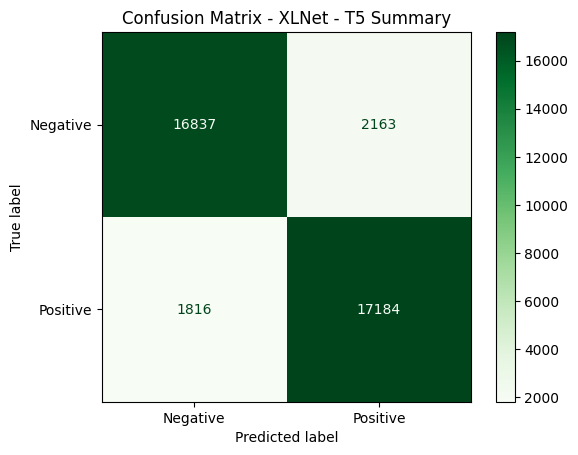

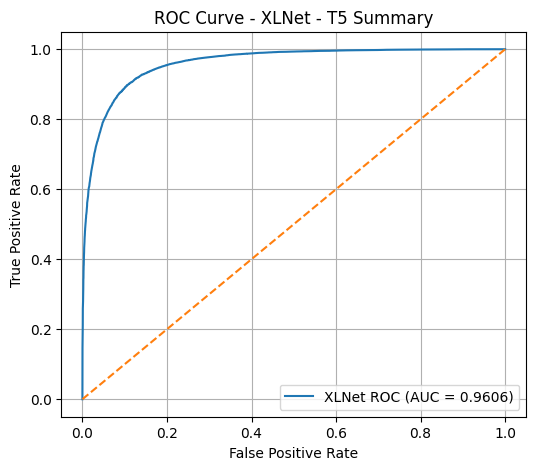

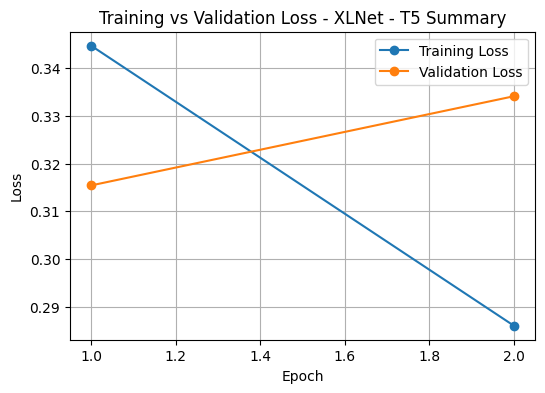


Saved final result:
/content/drive/MyDrive/yelp_t5_classification_outputs/xlnet_t5_results_final.csv

Saved full artifacts to:
/content/drive/MyDrive/yelp_t5_classification_outputs/xlnet_t5_single_summary


,Input Type,Summary Method,Summary Length,Model,Checkpoint,Optimizer,Max Length,Batch Size,Epochs,Learning Rate,...,Test Truncation %,Training Time (min),Training Time per Epoch (min),Inference Time (sec),Inference Latency per Sample (ms),Training Throughput (samples/sec),Inference Throughput (samples/sec),Peak Training GPU Memory (MB),Peak Inference GPU Memory (MB),Device
0,Summarised Text,T5,Single Abstractive Summary,XLNet,xlnet-base-cased,AdamW,256,8,2,0.00002,...,0.0,166.44,83.22,119.66,3.149,50.47,317.56,3183.69,1750.41,NVIDIA A100-SXM4-40GB


In [ ]:
# =====================================================
# YELP T5 SUMMARY CLASSIFICATION
# XLNET ONLY + FULL THESIS OUTPUTS
# Same params as BERT / previous XLNet runs
# =====================================================

!pip install -q pandas numpy matplotlib scikit-learn transformers datasets sentencepiece accelerate torch

import os, gc, re, time, random, warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
    EarlyStoppingCallback, set_seed
)

from google.colab import drive
drive.mount("/content/drive")

warnings.filterwarnings("ignore")

# =====================================================
# CONFIG
# =====================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print("Device:", device_name)

BASE_DIR = "/content/drive/MyDrive/yelp_t5_abstractive_outputs"
RUN_OUTPUT_DIR = "/content/drive/MyDrive/yelp_t5_classification_outputs"
OUTPUT_DIR = os.path.join(RUN_OUTPUT_DIR, "xlnet_t5_single_summary")
os.makedirs(OUTPUT_DIR, exist_ok=True)

TRAIN_PATH = f"{BASE_DIR}/yelp_t5_abstractive_train_for_classification.csv"
VAL_PATH = f"{BASE_DIR}/yelp_t5_abstractive_val_for_classification.csv"
TEST_PATH = f"{BASE_DIR}/yelp_t5_abstractive_test_for_classification.csv"

MODEL_LABEL = "XLNet"
MODEL_NAME = "xlnet-base-cased"

MAX_LENGTH = 256
EPOCHS = 2
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
BATCH_SIZE = 8
EARLY_STOPPING_PATIENCE = 1
OPTIMIZER_NAME = "AdamW"

FINAL_RESULTS_PATH = os.path.join(RUN_OUTPUT_DIR, "xlnet_t5_results_final.csv")

print("Train:", os.path.exists(TRAIN_PATH), TRAIN_PATH)
print("Val  :", os.path.exists(VAL_PATH), VAL_PATH)
print("Test :", os.path.exists(TEST_PATH), TEST_PATH)

# =====================================================
# HELPERS
# =====================================================
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)


def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.replace("<br />", " ")
    text = text.replace("\n", " ")
    text = text.replace("\t", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text


def reset_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()


def get_peak_gpu_memory_mb():
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / (1024 ** 2)
    return None


def format_seconds(seconds):
    if seconds < 60:
        return f"{seconds:.2f} sec"
    minutes = int(seconds // 60)
    rem = seconds % 60
    return f"{minutes} min {rem:.2f} sec"


@dataclass
class TokenStats:
    avg_tokens_before: float
    avg_tokens_after: float
    max_tokens_before: int
    truncated_count: int
    truncation_pct: float


def get_token_stats(texts, tokenizer, max_length=256, batch_size=512):
    full_lengths = []
    trunc_lengths = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        full_batch = tokenizer(
            batch,
            add_special_tokens=True,
            truncation=False,
            padding=False
        )

        trunc_batch = tokenizer(
            batch,
            truncation=True,
            padding=False,
            max_length=max_length
        )

        full_lengths.extend([len(x) for x in full_batch["input_ids"]])
        trunc_lengths.extend([len(x) for x in trunc_batch["input_ids"]])

    truncated_count = sum(1 for x in full_lengths if x > max_length)

    stats = TokenStats(
        avg_tokens_before=float(np.mean(full_lengths)),
        avg_tokens_after=float(np.mean(trunc_lengths)),
        max_tokens_before=int(np.max(full_lengths)),
        truncated_count=int(truncated_count),
        truncation_pct=float(truncated_count / len(full_lengths) * 100)
    )

    trunc_enc = tokenizer(
        texts,
        truncation=True,
        padding=False,
        max_length=max_length
    )

    return stats, trunc_enc


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, probs)
    }


def plot_confusion_matrix_save(y_true, y_pred, save_path):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"]
    )
    disp.plot(cmap="Greens")
    plt.title("Confusion Matrix - XLNet - T5 Summary")
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()
    return cm


def plot_roc_curve_save(y_true, y_prob, save_path):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc_value = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"XLNet ROC (AUC = {roc_auc_value:.4f})")
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - XLNet - T5 Summary")
    plt.legend()
    plt.grid(True)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()


def plot_train_val_loss_save(trainer, save_path):
    history = trainer.state.log_history
    train_loss, val_loss = [], []
    train_epochs, val_epochs = [], []

    for log in history:
        if "loss" in log and "epoch" in log and "eval_loss" not in log:
            train_loss.append(log["loss"])
            train_epochs.append(log["epoch"])
        if "eval_loss" in log and "epoch" in log:
            val_loss.append(log["eval_loss"])
            val_epochs.append(log["epoch"])

    if len(train_loss) == 0 or len(val_loss) == 0:
        print("Skipping loss plot: insufficient log history.")
        return

    plt.figure(figsize=(6, 4))
    plt.plot(train_epochs, train_loss, marker="o", label="Training Loss")
    plt.plot(val_epochs, val_loss, marker="o", label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss - XLNet - T5 Summary")
    plt.legend()
    plt.grid(True)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()


# =====================================================
# LOAD DATA
# =====================================================
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    if "text" not in df.columns or "label" not in df.columns:
        raise ValueError(f"{name} file must contain columns: text, label")

train_texts = train_df["text"].fillna("").astype(str).apply(clean_text).tolist()
val_texts = val_df["text"].fillna("").astype(str).apply(clean_text).tolist()
test_texts = test_df["text"].fillna("").astype(str).apply(clean_text).tolist()

train_labels = train_df["label"].astype(int).tolist()
val_labels = val_df["label"].astype(int).tolist()
test_labels = test_df["label"].astype(int).tolist()

print("Train:", len(train_texts))
print("Val  :", len(val_texts))
print("Test :", len(test_texts))

# =====================================================
# TOKENIZE
# =====================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token if tokenizer.eos_token is not None else tokenizer.unk_token

train_stats, train_enc = get_token_stats(train_texts, tokenizer, max_length=MAX_LENGTH)
val_stats, val_enc = get_token_stats(val_texts, tokenizer, max_length=MAX_LENGTH)
test_stats, test_enc = get_token_stats(test_texts, tokenizer, max_length=MAX_LENGTH)

print("\n=== TOKEN / TRUNCATION STATS ===")
print("Train avg tokens before trunc:", round(train_stats.avg_tokens_before, 2))
print("Train avg tokens after trunc :", round(train_stats.avg_tokens_after, 2))
print("Train truncation %          :", round(train_stats.truncation_pct, 2))
print("Test avg tokens before trunc:", round(test_stats.avg_tokens_before, 2))
print("Test avg tokens after trunc :", round(test_stats.avg_tokens_after, 2))
print("Test truncation %           :", round(test_stats.truncation_pct, 2))

train_dataset = TextDataset(train_enc, train_labels)
val_dataset = TextDataset(val_enc, val_labels)
test_dataset = TextDataset(test_enc, test_labels)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# =====================================================
# MODEL + TRAINER
# =====================================================
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

if model.config.pad_token_id is None:
    model.config.pad_token_id = tokenizer.pad_token_id

args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    save_total_limit=1,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
    optim="adamw_torch"
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)]
)

# =====================================================
# TRAIN
# =====================================================
reset_gpu_memory()
train_start = time.time()
trainer.train()
train_time = time.time() - train_start
peak_train_mem = get_peak_gpu_memory_mb()

# =====================================================
# TEST / INFERENCE
# =====================================================
reset_gpu_memory()
infer_start = time.time()
pred = trainer.predict(test_dataset)
infer_time = time.time() - infer_start
peak_infer_mem = get_peak_gpu_memory_mb()

y_true = np.array(test_labels)
y_pred = np.argmax(pred.predictions, axis=1)
y_prob = torch.softmax(torch.tensor(pred.predictions), dim=1)[:, 1].numpy()

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
roc_auc_value = roc_auc_score(y_true, y_prob)

num_train = len(train_dataset)
num_val = len(val_dataset)
num_test = len(test_dataset)

train_time_per_epoch = train_time / EPOCHS
train_samples_per_sec = num_train / train_time
infer_samples_per_sec = num_test / infer_time
infer_latency_per_sample_ms = (infer_time / num_test) * 1000

print("\n=== FINAL XLNET T5 RESULTS ===")
print("Accuracy :", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall   :", round(rec, 4))
print("F1       :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc_value, 4))
print("Training time:", format_seconds(train_time))
print("Inference time:", format_seconds(infer_time))
print("Inference latency per sample (ms):", round(infer_latency_per_sample_ms, 4))
print("Training throughput:", round(train_samples_per_sec, 2), "samples/sec")
print("Inference throughput:", round(infer_samples_per_sec, 2), "samples/sec")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Negative", "Positive"],
    zero_division=0
))

# =====================================================
# SAVE ARTIFACTS
# =====================================================
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=["Negative", "Positive"],
    zero_division=0,
    output_dict=True
)

cm = plot_confusion_matrix_save(
    y_true,
    y_pred,
    os.path.join(OUTPUT_DIR, "xlnet_t5_confusion_matrix.png")
)

pd.DataFrame(
    cm,
    index=["Actual_Negative", "Actual_Positive"],
    columns=["Pred_Negative", "Pred_Positive"]
).to_csv(
    os.path.join(OUTPUT_DIR, "xlnet_t5_confusion_matrix_values.csv")
)

plot_roc_curve_save(
    y_true,
    y_prob,
    os.path.join(OUTPUT_DIR, "xlnet_t5_roc_curve.png")
)

plot_train_val_loss_save(
    trainer,
    os.path.join(OUTPUT_DIR, "xlnet_t5_train_val_loss.png")
)

pd.DataFrame(report_dict).transpose().to_csv(
    os.path.join(OUTPUT_DIR, "xlnet_t5_classification_report.csv")
)

pd.DataFrame(trainer.state.log_history).to_csv(
    os.path.join(OUTPUT_DIR, "xlnet_t5_training_log_history.csv"),
    index=False
)

pd.DataFrame({
    "true_label": y_true,
    "pred_label": y_pred,
    "prob_positive": y_prob
}).to_csv(
    os.path.join(OUTPUT_DIR, "xlnet_t5_test_predictions.csv"),
    index=False
)

result = {
    "Input Type": "Summarised Text",
    "Summary Method": "T5",
    "Summary Length": "Single Abstractive Summary",
    "Model": MODEL_LABEL,
    "Checkpoint": MODEL_NAME,
    "Optimizer": OPTIMIZER_NAME,
    "Max Length": MAX_LENGTH,
    "Batch Size": BATCH_SIZE,
    "Epochs": EPOCHS,
    "Learning Rate": LEARNING_RATE,
    "Weight Decay": WEIGHT_DECAY,

    "Accuracy": round(acc, 4),
    "Precision": round(prec, 4),
    "Recall": round(rec, 4),
    "F1": round(f1, 4),
    "ROC-AUC": round(roc_auc_value, 4),

    "Train Samples": num_train,
    "Validation Samples": num_val,
    "Test Samples": num_test,

    "Avg Train Tokens Before Trunc": round(train_stats.avg_tokens_before, 2),
    "Avg Train Tokens After Trunc": round(train_stats.avg_tokens_after, 2),
    "Max Train Tokens Before Trunc": train_stats.max_tokens_before,
    "Train Truncated Count": train_stats.truncated_count,
    "Train Truncation %": round(train_stats.truncation_pct, 2),

    "Avg Test Tokens Before Trunc": round(test_stats.avg_tokens_before, 2),
    "Avg Test Tokens After Trunc": round(test_stats.avg_tokens_after, 2),
    "Max Test Tokens Before Trunc": test_stats.max_tokens_before,
    "Test Truncated Count": test_stats.truncated_count,
    "Test Truncation %": round(test_stats.truncation_pct, 2),

    "Training Time (min)": round(train_time / 60, 2),
    "Training Time per Epoch (min)": round(train_time_per_epoch / 60, 2),
    "Inference Time (sec)": round(infer_time, 2),
    "Inference Latency per Sample (ms)": round(infer_latency_per_sample_ms, 4),
    "Training Throughput (samples/sec)": round(train_samples_per_sec, 2),
    "Inference Throughput (samples/sec)": round(infer_samples_per_sec, 2),
    "Peak Training GPU Memory (MB)": round(peak_train_mem, 2) if peak_train_mem is not None else None,
    "Peak Inference GPU Memory (MB)": round(peak_infer_mem, 2) if peak_infer_mem is not None else None,
    "Device": device_name
}

results_df = pd.DataFrame([result])
results_df.to_csv(FINAL_RESULTS_PATH, index=False)
results_df.to_csv(os.path.join(OUTPUT_DIR, "xlnet_t5_metrics.csv"), index=False)

print("\nSaved final result:")
print(FINAL_RESULTS_PATH)

print("\nSaved full artifacts to:")
print(OUTPUT_DIR)

display(results_df)